# Mineração de Dados — Heart Disease

Pergunta do trabalho: **entre pacientes avaliados para doença arterial coronariana, quais perfis clínicos se parecem e é possível classificar a presença da doença a partir dos exames disponíveis?**

Este notebook segue o fluxo visto em aula:

1. Preparar os dados
2. Explorar os dados
3. Agrupar registros parecidos (K-Means)
4. Classificar um registro em uma classe conhecida (árvore de decisão)

A classe usada na classificação é o diagnóstico que já vem na base. O agrupamento não inventa esse rótulo: ele só procura pacientes com exames parecidos.

## Base escolhida

| Item | Conteúdo |
|---|---|
| Nome | Heart Disease |
| Link | https://archive.ics.uci.edu/dataset/45/heart+disease |
| Instituições | Cleveland Clinic Foundation; Hungarian Institute of Cardiology (Budapeste); University Hospital, Zurique; V.A. Medical Center, Long Beach |
| Autores | Andras Janosi, William Steinbrunn, Matthias Pfisterer e Robert Detrano (1989) |
| Licença | CC BY 4.0 |
| Citação | Janosi, A., Steinbrunn, W., Pfisterer, M., & Detrano, R. (1989). Heart Disease. UCI Machine Learning Repository. https://doi.org/10.24432/C52P4X |

A página do UCI destaca 303 pacientes de Cleveland. Neste trabalho usamos os **quatro hospitais**, no mesmo formato de 14 colunas, para enxergar a qualidade dos dados de cada origem. São 920 fichas no total.

A classe original se chama `num`: 0 é ausência de estreitamento relevante da artéria; 1 a 4 são graus de presença. Como nos experimentos clássicos desta base, vamos transformar isso em duas classes: **ausência (0)** e **presença (1)**.

## Instalação e importação das bibliotecas

No Google Colab estas bibliotecas já estão instaladas. Usamos:

- **pandas:** manipulação dos dados
- **numpy:** operações numéricas
- **matplotlib e seaborn:** gráficos
- **scikit-learn:** agrupamento e classificação

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.metrics import classification_report, confusion_matrix, silhouette_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)


Matplotlib is building the font cache; this may take a moment.


## Carregando o dataset

Os arquivos processados do UCI não trazem cabeçalho. O valor ausente está marcado com `?`. Cada arquivo é um hospital. Juntamos os quatro e guardamos a origem na coluna `hospital`.

In [2]:
colunas = [
    "age", "sex", "cp", "trestbps", "chol", "fbs", "restecg",
    "thalach", "exang", "oldpeak", "slope", "ca", "thal", "num",
]

arquivos = {
    "Cleveland": "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data",
    "Hungria": "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.hungarian.data",
    "Suica": "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.switzerland.data",
    "Long Beach": "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.va.data",
}

nomes_hospitais = {
    "Cleveland": "Cleveland",
    "Hungria": "Hungria",
    "Suica": "Suíça",
    "Long Beach": "Long Beach",
}

partes = []
for hospital, url in arquivos.items():
    parte = pd.read_csv(url, header=None, names=colunas, na_values="?")
    parte["hospital"] = hospital
    partes.append(parte)

df = pd.concat(partes, ignore_index=True)
df["hospital_nome"] = df["hospital"].map(nomes_hospitais)

print("Fichas carregadas:", len(df))
print("Hospitais:")
display(df["hospital_nome"].value_counts().rename("fichas"))


Fichas carregadas: 920
Hospitais:


hospital_nome
Cleveland     303
Hungria       294
Long Beach    200
Suíça         123
Name: fichas, dtype: int64

## Conhecendo os dados

Antes de aplicar qualquer algoritmo, precisamos entender o que cada coluna significa e onde os dados faltam.

| Coluna | Significado |
|---|---|
| age | Idade, em anos |
| sex | Sexo (0 = feminino, 1 = masculino) |
| cp | Tipo de dor no peito (1 = angina típica, 2 = atípica, 3 = dor não anginosa, 4 = assintomático) |
| trestbps | Pressão arterial em repouso, em mm Hg |
| chol | Colesterol sérico, em mg/dl |
| fbs | Glicemia de jejum acima de 120 mg/dl (1 = sim, 0 = não) |
| restecg | Eletrocardiograma em repouso (0 = normal, 1 = anomalia de ST-T, 2 = hipertrofia ventricular) |
| thalach | Frequência cardíaca máxima atingida |
| exang | Angina provocada por exercício (1 = sim, 0 = não) |
| oldpeak | Depressão do segmento ST induzida pelo exercício |
| slope | Inclinação do segmento ST |
| ca | Número de vasos principais visíveis na fluoroscopia (0 a 3) |
| thal | Resultado do exame de tálio |
| num | Diagnóstico angiográfico (0 = ausência, 1 a 4 = presença em graus) |
| hospital | Origem da ficha |

In [3]:
print("Tipos e quantidade de valores preenchidos:")
df.info()

print("\nPrimeiras linhas:")
display(df.head())

print("\nEstatísticas das variáveis numéricas:")
display(df.describe().round(2))


Tipos e quantidade de valores preenchidos:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   age            920 non-null    float64
 1   sex            920 non-null    float64
 2   cp             920 non-null    float64
 3   trestbps       861 non-null    float64
 4   chol           890 non-null    float64
 5   fbs            830 non-null    float64
 6   restecg        918 non-null    float64
 7   thalach        865 non-null    float64
 8   exang          865 non-null    float64
 9   oldpeak        858 non-null    float64
 10  slope          611 non-null    float64
 11  ca             309 non-null    float64
 12  thal           434 non-null    float64
 13  num            920 non-null    int64  
 14  hospital       920 non-null    object 
 15  hospital_nome  920 non-null    object 
dtypes: float64(13), int64(1), object(2)
memory usage: 115.1

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num,hospital,hospital_nome
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0,Cleveland,Cleveland
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2,Cleveland,Cleveland
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1,Cleveland,Cleveland
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0,Cleveland,Cleveland
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0,Cleveland,Cleveland



Estatísticas das variáveis numéricas:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
count,920.00,920.00,920.00,861.00,890.00,830.00,918.00,865.00,865.00,858.00,611.00,309.00,434.00,920.00
mean,53.51,0.79,3.25,132.13,199.13,0.17,0.60,137.55,0.39,0.88,1.77,0.68,5.09,1.00
std,9.42,0.41,0.93,19.07,110.78,0.37,0.81,25.93,0.49,1.09,0.62,0.94,1.92,1.14
min,28.00,0.00,1.00,0.00,0.00,0.00,0.00,60.00,0.00,-2.60,1.00,0.00,3.00,0.00
25%,47.00,1.00,3.00,120.00,175.00,0.00,0.00,120.00,0.00,0.00,1.00,0.00,3.00,0.00
50%,54.00,1.00,4.00,130.00,223.00,0.00,0.00,140.00,0.00,0.50,2.00,0.00,6.00,1.00
75%,60.00,1.00,4.00,140.00,268.00,0.00,1.00,157.00,1.00,1.50,2.00,1.00,7.00,2.00
max,77.00,1.00,4.00,200.00,603.00,1.00,2.00,202.00,1.00,6.20,3.00,3.00,7.00,4.00


In [4]:
print("Valores ausentes (marcados como ? no arquivo original):")
ausentes = df[colunas].isna().sum().sort_values(ascending=False)
display(ausentes)

print("\nDiagnóstico original (num), por hospital:")
display(pd.crosstab(df["hospital_nome"], df["num"], margins=True))


Valores ausentes (marcados como ? no arquivo original):


ca          611
thal        486
slope       309
fbs          90
oldpeak      62
trestbps     59
thalach      55
exang        55
chol         30
restecg       2
cp            0
sex           0
age           0
num           0
dtype: int64


Diagnóstico original (num), por hospital:


num,0,1,2,3,4,All
hospital_nome,,,,,,
Cleveland,164,55,36,35,13,303
Hungria,188,106,0,0,0,294
Long Beach,51,56,41,42,10,200
Suíça,8,48,32,30,5,123
All,411,265,109,107,28,920


### O que devemos observar?

- `ca`, `thal` e `slope` faltam em grande parte das fichas fora de Cleveland.
- Na Suíça, o colesterol veio todo como **0**. Zero não é um colesterol medido: é ausência de dado escrita de outro jeito.
- Em Long Beach também aparecem colesteróis iguais a zero.
- A Hungria só usa `num` 0 e 1. Os outros hospitais usam 0 a 4. Por isso a classe do trabalho será binária: ausência ou presença.
- A proporção de doença muda muito de um hospital para outro. Isso precisa aparecer na interpretação.

Percentual de colesterol igual a zero, por hospital:


hospital_nome
Cleveland       0.0
Hungria         0.0
Long Beach     24.5
Suíça         100.0
Name: % colesterol = 0, dtype: float64

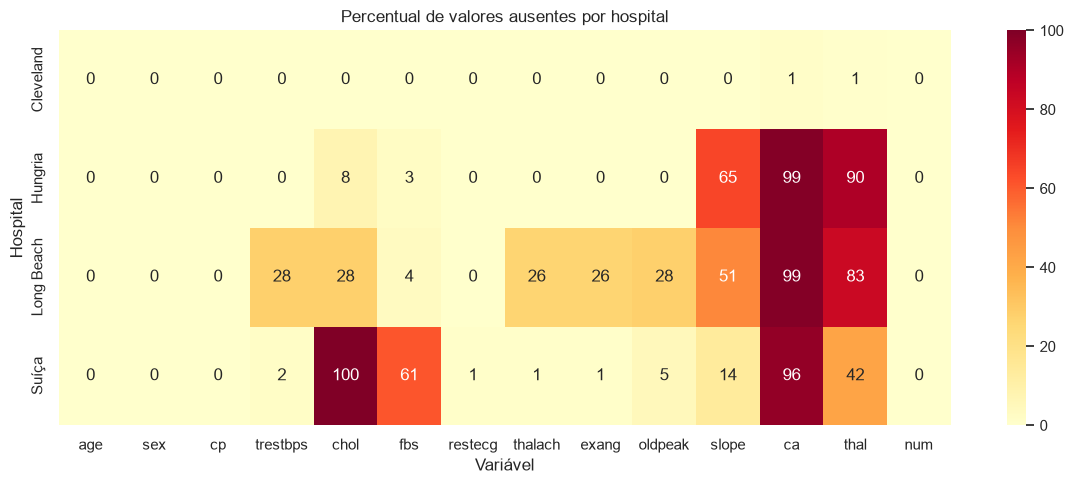

In [5]:
chol_zero = df["chol"].eq(0).groupby(df["hospital_nome"]).mean().mul(100).round(1)
print("Percentual de colesterol igual a zero, por hospital:")
display(chol_zero.rename("% colesterol = 0"))

qualidade = df.copy()
qualidade.loc[qualidade["chol"].eq(0), "chol"] = np.nan
percentual_ausente = (
    qualidade.groupby("hospital_nome")[colunas]
    .apply(lambda g: g.isna().mean().mul(100))
    .round(1)
)

plt.figure(figsize=(12, 5))
sns.heatmap(percentual_ausente, annot=True, fmt=".0f", cmap="YlOrRd", vmin=0, vmax=100)
plt.title("Percentual de valores ausentes por hospital")
plt.xlabel("Variável")
plt.ylabel("Hospital")
plt.tight_layout()
plt.show()


## Preparação dos dados

Regras usadas neste trabalho:

1. Tratar colesterol igual a zero como valor ausente.
2. Retirar `slope`, `ca` e `thal`. Essas colunas passam de 30% de ausência e, fora de Cleveland, quase não existem. Mantê-las reduziria o estudo a um único hospital.
3. Manter idade, sexo, tipo de dor, pressão, colesterol, glicemia, eletrocardiograma, frequência cardíaca máxima, angina de exercício e depressão de ST.
4. Remover a ficha inteira quando um desses exames mantidos estiver vazio. Não vamos inventar o valor que faltou.
5. Criar a coluna `doenca`: 0 se `num` é 0, e 1 se `num` é 1, 2, 3 ou 4.

A Suíça sai da análise final porque nenhuma ficha de lá tem colesterol real. Isso fica registrado de propósito: é uma decisão de qualidade de dados, não um filtro escondido.

In [6]:
dados = df.copy()
dados.loc[dados["chol"].eq(0), "chol"] = np.nan

colunas_descartadas = ["slope", "ca", "thal"]
colunas_modelo = [
    "age", "sex", "cp", "trestbps", "chol", "fbs",
    "restecg", "thalach", "exang", "oldpeak",
]

antes = dados.groupby("hospital_nome").size().rename("fichas_originais")
completas = dados.dropna(subset=colunas_modelo)
depois = completas.groupby("hospital_nome").size().rename("fichas_usadas")

comparacao = pd.concat([antes, depois], axis=1).fillna(0).astype(int)
comparacao["removidas"] = comparacao["fichas_originais"] - comparacao["fichas_usadas"]
print("Efeito da limpeza por hospital:")
display(comparacao)
print("Colunas retiradas da modelagem:", ", ".join(colunas_descartadas))
print("Fichas usadas na mineração:", len(completas), "de", len(df))

dados = completas.copy()
dados["doenca"] = (dados["num"] > 0).astype(int)

print("\nClasse binária (0 = ausência, 1 = presença):")
display(dados["doenca"].value_counts().rename("fichas"))
print("Proporção de presença: {:.1%}".format(dados["doenca"].mean()))


Efeito da limpeza por hospital:


,fichas_originais,fichas_usadas,removidas
hospital_nome,,,
Cleveland,303,303,0
Hungria,294,261,33
Long Beach,200,97,103
Suíça,123,0,123


Colunas retiradas da modelagem: slope, ca, thal
Fichas usadas na mineração: 661 de 920

Classe binária (0 = ausência, 1 = presença):


doenca
0    347
1    314
Name: fichas, dtype: int64

Proporção de presença: 47.5%


## Visualização inicial

A primeira pergunta descritiva é: **a presença da doença está distribuída do mesmo jeito nos hospitais e nos tipos de dor?**

Estes gráficos ainda não são o agrupamento nem a classificação. Eles mostram o terreno em que os algoritmos vão trabalhar.

Presença de doença nas fichas que permaneceram:


,fichas,proporcao_presenca
hospital_nome,,
Hungria,261,37.5
Cleveland,303,45.9
Long Beach,97,79.4


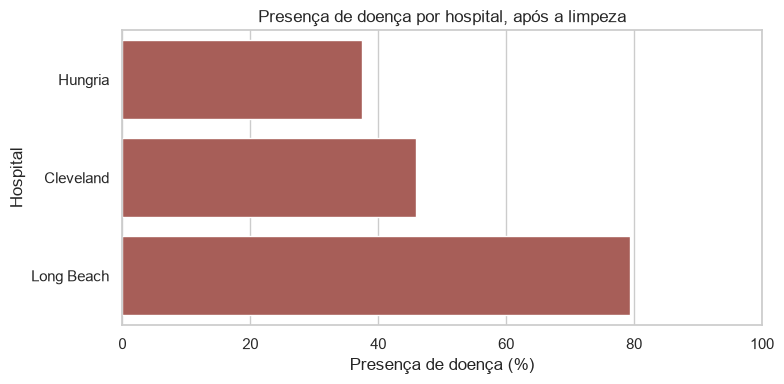

In [7]:
rotulos_cp = {
    1: "Angina típica",
    2: "Angina atípica",
    3: "Dor não anginosa",
    4: "Assintomático",
}

prevalencia = (
    dados.groupby("hospital_nome")["doenca"]
    .agg(fichas="size", proporcao_presenca="mean")
    .sort_values("proporcao_presenca")
)
prevalencia["proporcao_presenca"] = (prevalencia["proporcao_presenca"] * 100).round(1)
print("Presença de doença nas fichas que permaneceram:")
display(prevalencia)

plt.figure(figsize=(8, 4))
sns.barplot(
    data=prevalencia.reset_index(),
    x="proporcao_presenca",
    y="hospital_nome",
    color="#b4534b",
)
plt.xlabel("Presença de doença (%)")
plt.ylabel("Hospital")
plt.title("Presença de doença por hospital, após a limpeza")
plt.xlim(0, 100)
plt.tight_layout()
plt.show()


Presença de doença por tipo de dor no peito:


,fichas,proporcao_presenca
tipo_dor,,
Angina típica,35,34.3
Angina atípica,148,13.5
Dor não anginosa,144,25.0
Assintomático,334,73.7


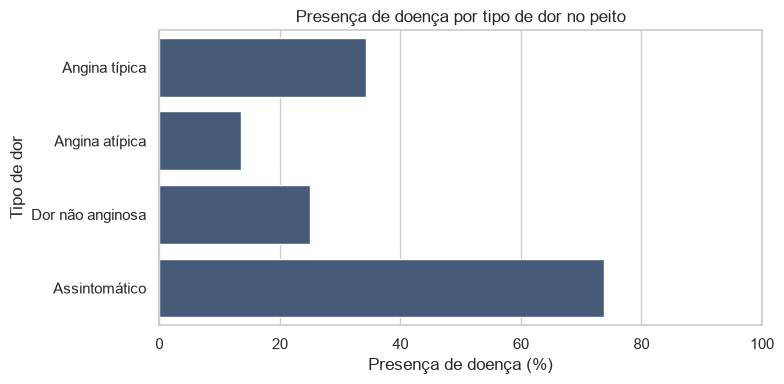

In [8]:
por_dor = dados.copy()
por_dor["tipo_dor"] = por_dor["cp"].astype(int).map(rotulos_cp)
resumo_dor = (
    por_dor.groupby("tipo_dor")["doenca"]
    .agg(fichas="size", proporcao_presenca="mean")
    .reindex(rotulos_cp.values())
)
resumo_dor["proporcao_presenca"] = (resumo_dor["proporcao_presenca"] * 100).round(1)
print("Presença de doença por tipo de dor no peito:")
display(resumo_dor)

plt.figure(figsize=(8, 4))
sns.barplot(
    data=resumo_dor.reset_index(),
    x="proporcao_presenca",
    y="tipo_dor",
    color="#3d5a80",
)
plt.xlabel("Presença de doença (%)")
plt.ylabel("Tipo de dor")
plt.title("Presença de doença por tipo de dor no peito")
plt.xlim(0, 100)
plt.tight_layout()
plt.show()


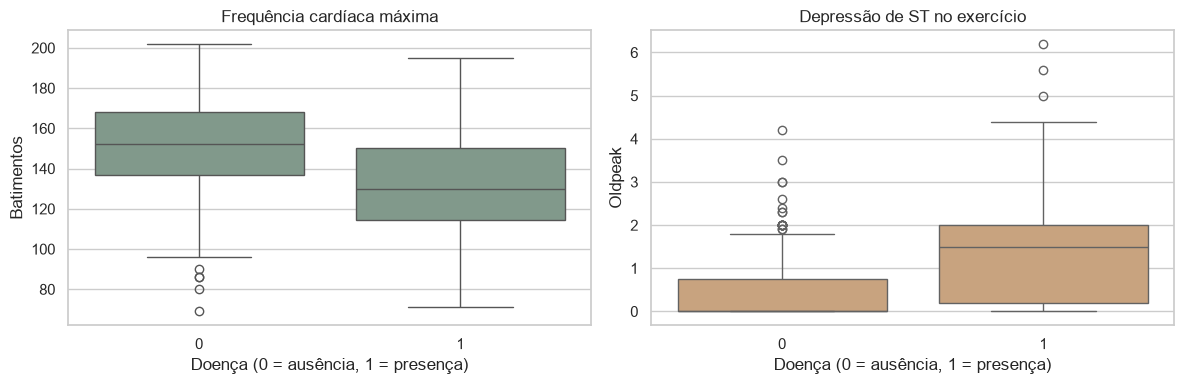

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.boxplot(data=dados, x="doenca", y="thalach", ax=axes[0], color="#7d9d8a")
axes[0].set_title("Frequência cardíaca máxima")
axes[0].set_xlabel("Doença (0 = ausência, 1 = presença)")
axes[0].set_ylabel("Batimentos")

sns.boxplot(data=dados, x="doenca", y="oldpeak", ax=axes[1], color="#d4a373")
axes[1].set_title("Depressão de ST no exercício")
axes[1].set_xlabel("Doença (0 = ausência, 1 = presença)")
axes[1].set_ylabel("Oldpeak")

plt.tight_layout()
plt.show()


# Agrupamento com K-Means

O K-Means junta pacientes com exames parecidos. Ele **não recebe** a coluna `doenca`. Se os grupos coincidirem em parte com a presença da doença, isso é uma leitura feita depois, não uma resposta que o algoritmo já conhecia.

`cp` e `restecg` são códigos de categoria. O número 4 não significa “duas vezes o tipo 2”. Por isso essas colunas viram indicadores (uma coluna para cada categoria) antes do agrupamento.

As escalas também são diferentes: idade fica perto de 50, colesterol perto de 250 e angina é 0 ou 1. A padronização coloca tudo na mesma escala para nenhuma coluna dominar a distância.

In [10]:
def montar_atributos(base):
    tabela = base[colunas_modelo].copy()
    for coluna in ["sex", "cp", "fbs", "restecg", "exang"]:
        tabela[coluna] = tabela[coluna].astype(int)
    tabela = pd.get_dummies(tabela, columns=["cp", "restecg"])
    return tabela.rename(columns={
        "age": "idade",
        "sex": "sexo_masculino",
        "trestbps": "pressao_repouso",
        "chol": "colesterol",
        "fbs": "glicemia_alta",
        "thalach": "freq_cardiaca_max",
        "exang": "angina_exercicio",
        "oldpeak": "depressao_st",
        "cp_1": "dor_angina_tipica",
        "cp_2": "dor_angina_atipica",
        "cp_3": "dor_nao_anginosa",
        "cp_4": "assintomatico",
        "restecg_0": "ecg_normal",
        "restecg_1": "ecg_anomalia_st",
        "restecg_2": "ecg_hipertrofia",
    })

X = montar_atributos(dados)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Atributos usados no agrupamento e na classificação:")
print(", ".join(X.columns))
print("Pacientes:", X.shape[0])


Atributos usados no agrupamento e na classificação:
idade, sexo_masculino, pressao_repouso, colesterol, glicemia_alta, freq_cardiaca_max, angina_exercicio, depressao_st, dor_angina_tipica, dor_angina_atipica, dor_nao_anginosa, assintomatico, ecg_normal, ecg_anomalia_st, ecg_hipertrofia
Pacientes: 661


## Escolha do número de grupos

O Silhouette Score resume se os pacientes ficam mais perto do próprio grupo do que dos outros. Perto de 1, os grupos estão bem separados. Perto de 0, eles se misturam.

Nesta base o escore fica baixo para qualquer quantidade de grupos. Isso já é um resultado: os perfis clínicos se sobrepõem. Vamos testar de 2 a 6 grupos e ficar com **2**, porque é a divisão que ainda dá para explicar na apresentação. Grupos a mais só quebram o lado de menor risco em perfis muito parecidos entre si.

,grupos,silhouette
0,2,0.157
1,3,0.184
2,4,0.211
3,5,0.202
4,6,0.225


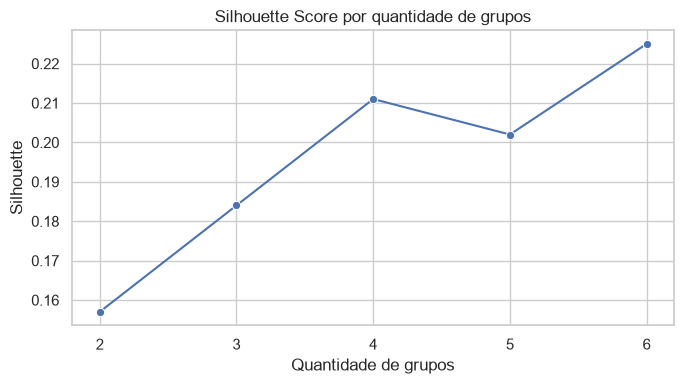

In [11]:
silhuetas = []
for k in range(2, 7):
    rotulos = KMeans(n_clusters=k, n_init=20, random_state=42).fit_predict(X_scaled)
    escore = silhouette_score(X_scaled, rotulos)
    silhuetas.append({"grupos": k, "silhouette": round(escore, 3)})

tabela_silhueta = pd.DataFrame(silhuetas)
display(tabela_silhueta)

plt.figure(figsize=(7, 4))
sns.lineplot(data=tabela_silhueta, x="grupos", y="silhouette", marker="o")
plt.title("Silhouette Score por quantidade de grupos")
plt.xlabel("Quantidade de grupos")
plt.ylabel("Silhouette")
plt.xticks(tabela_silhueta["grupos"])
plt.tight_layout()
plt.show()


In [12]:
k_escolhido = 2
dados["cluster"] = KMeans(
    n_clusters=k_escolhido, n_init=20, random_state=42
).fit_predict(X_scaled)

perfil = (
    dados.groupby("cluster")[["age", "trestbps", "chol", "thalach", "oldpeak", "exang", "doenca"]]
    .mean()
    .round(2)
)
perfil["fichas"] = dados.groupby("cluster").size()
print("Perfil médio de cada grupo:")
display(perfil)

print("Grupos por hospital:")
display(pd.crosstab(dados["cluster"], dados["hospital_nome"]))


Perfil médio de cada grupo:


,age,trestbps,chol,thalach,oldpeak,exang,doenca,fichas
cluster,,,,,,,,
0,56.60,136.86,253.22,125.25,1.52,0.75,0.80,297
1,49.36,129.48,240.92,154.18,0.41,0.07,0.21,364


Grupos por hospital:


hospital_nome,Cleveland,Hungria,Long Beach
cluster,,,
0,122,90,85
1,181,171,12


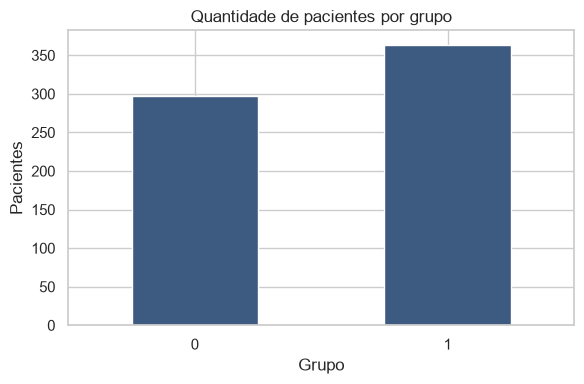

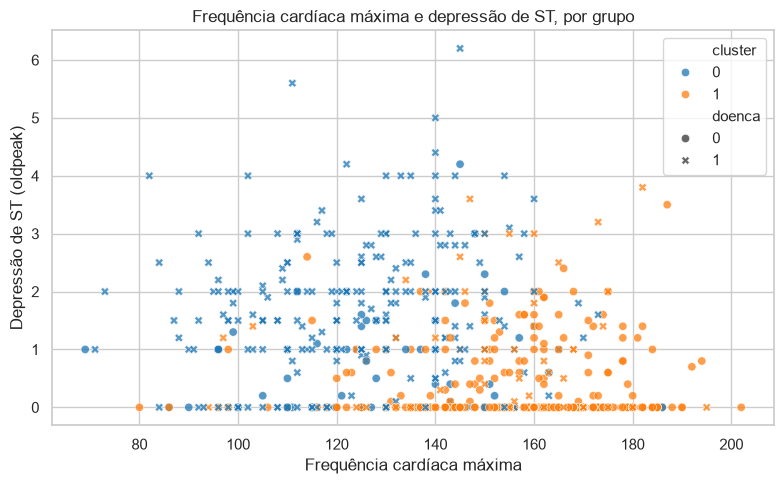

In [13]:
contagem = dados["cluster"].value_counts().sort_index()
plt.figure(figsize=(6, 4))
contagem.plot(kind="bar", color="#3d5a80")
plt.title("Quantidade de pacientes por grupo")
plt.xlabel("Grupo")
plt.ylabel("Pacientes")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=dados,
    x="thalach",
    y="oldpeak",
    hue="cluster",
    style="doenca",
    palette="tab10",
    alpha=0.75,
)
plt.title("Frequência cardíaca máxima e depressão de ST, por grupo")
plt.xlabel("Frequência cardíaca máxima")
plt.ylabel("Depressão de ST (oldpeak)")
plt.tight_layout()
plt.show()


### Como ler os grupos

O número do grupo é só um identificador. A leitura usa as médias.

No resultado desta execução, um grupo reúne pacientes mais velhos, com frequência cardíaca máxima mais baixa, mais angina de exercício, depressão de ST mais alta e cerca de 80% de presença da doença. O outro reúne pacientes mais novos, com frequência cardíaca máxima mais alta, pouca angina e cerca de 20% de presença.

Isso é associação entre o perfil e o diagnóstico. Não quer dizer que a idade ou o exame tenha causado a doença. O Silhouette baixo confirma que a fronteira entre os grupos não é nítida: muita gente fica no meio do caminho.

# Classificação

A classificação é diferente do agrupamento. Aqui existe uma classe conhecida: ausência ou presença de doença arterial coronariana, vinda da angiografia (`num`).

A árvore de decisão aprende regras do tipo “se o paciente é assintomático e a depressão de ST passa de um certo valor, classifique como presença”. Ela é adequada a este trabalho porque a regra pode ser mostrada e explicada.

O hospital **não entra** como atributo. Se entrasse, a árvore poderia aprender “este hospital tem mais doentes” em vez de aprender o exame.

Separamos 75% das fichas para treinar e 25% para testar. O teste é estratificado: a proporção de presença é parecida nos dois lados. A profundidade máxima é 4, para a árvore caber na apresentação.

In [14]:
y = dados["doenca"]

X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

modelo = DecisionTreeClassifier(max_depth=4, random_state=42)
modelo.fit(X_treino, y_treino)
y_previsto = modelo.predict(X_teste)

maioria = y.value_counts(normalize=True).max()
print("Acerto se chute sempre a classe mais comum: {:.1%}".format(maioria))
print("Fichas de treino:", len(X_treino), "| Fichas de teste:", len(X_teste))


Acerto se chute sempre a classe mais comum: 52.5%
Fichas de treino: 495 | Fichas de teste: 166


## Avaliando o classificador

A acurácia sozinha engana quando uma classe é muito maior que a outra. Aqui as duas classes estão próximas, mas ainda assim olhamos precisão, recall e a matriz de confusão.

- **Precisão da presença:** entre quem o modelo marcou como presença, quantos realmente tinham doença.
- **Recall da presença:** entre quem tinha doença, quantos o modelo encontrou.
- O erro mais grave neste tema é o falso negativo: o modelo diz ausência e a ficha é presença.

In [15]:
print("Relatório de classificação:")
print(classification_report(
    y_teste,
    y_previsto,
    target_names=["Ausência", "Presença"],
    digits=3,
))

matriz = pd.DataFrame(
    confusion_matrix(y_teste, y_previsto),
    index=["Ausência real", "Presença real"],
    columns=["Prevista ausência", "Prevista presença"],
)
print("Matriz de confusão:")
display(matriz)


Relatório de classificação:
              precision    recall  f1-score   support

    Ausência      0.847     0.701     0.767        87
    Presença      0.723     0.861     0.786        79

    accuracy                          0.777       166
   macro avg      0.785     0.781     0.777       166
weighted avg      0.788     0.777     0.776       166

Matriz de confusão:


,Prevista ausência,Prevista presença
Ausência real,61,26
Presença real,11,68


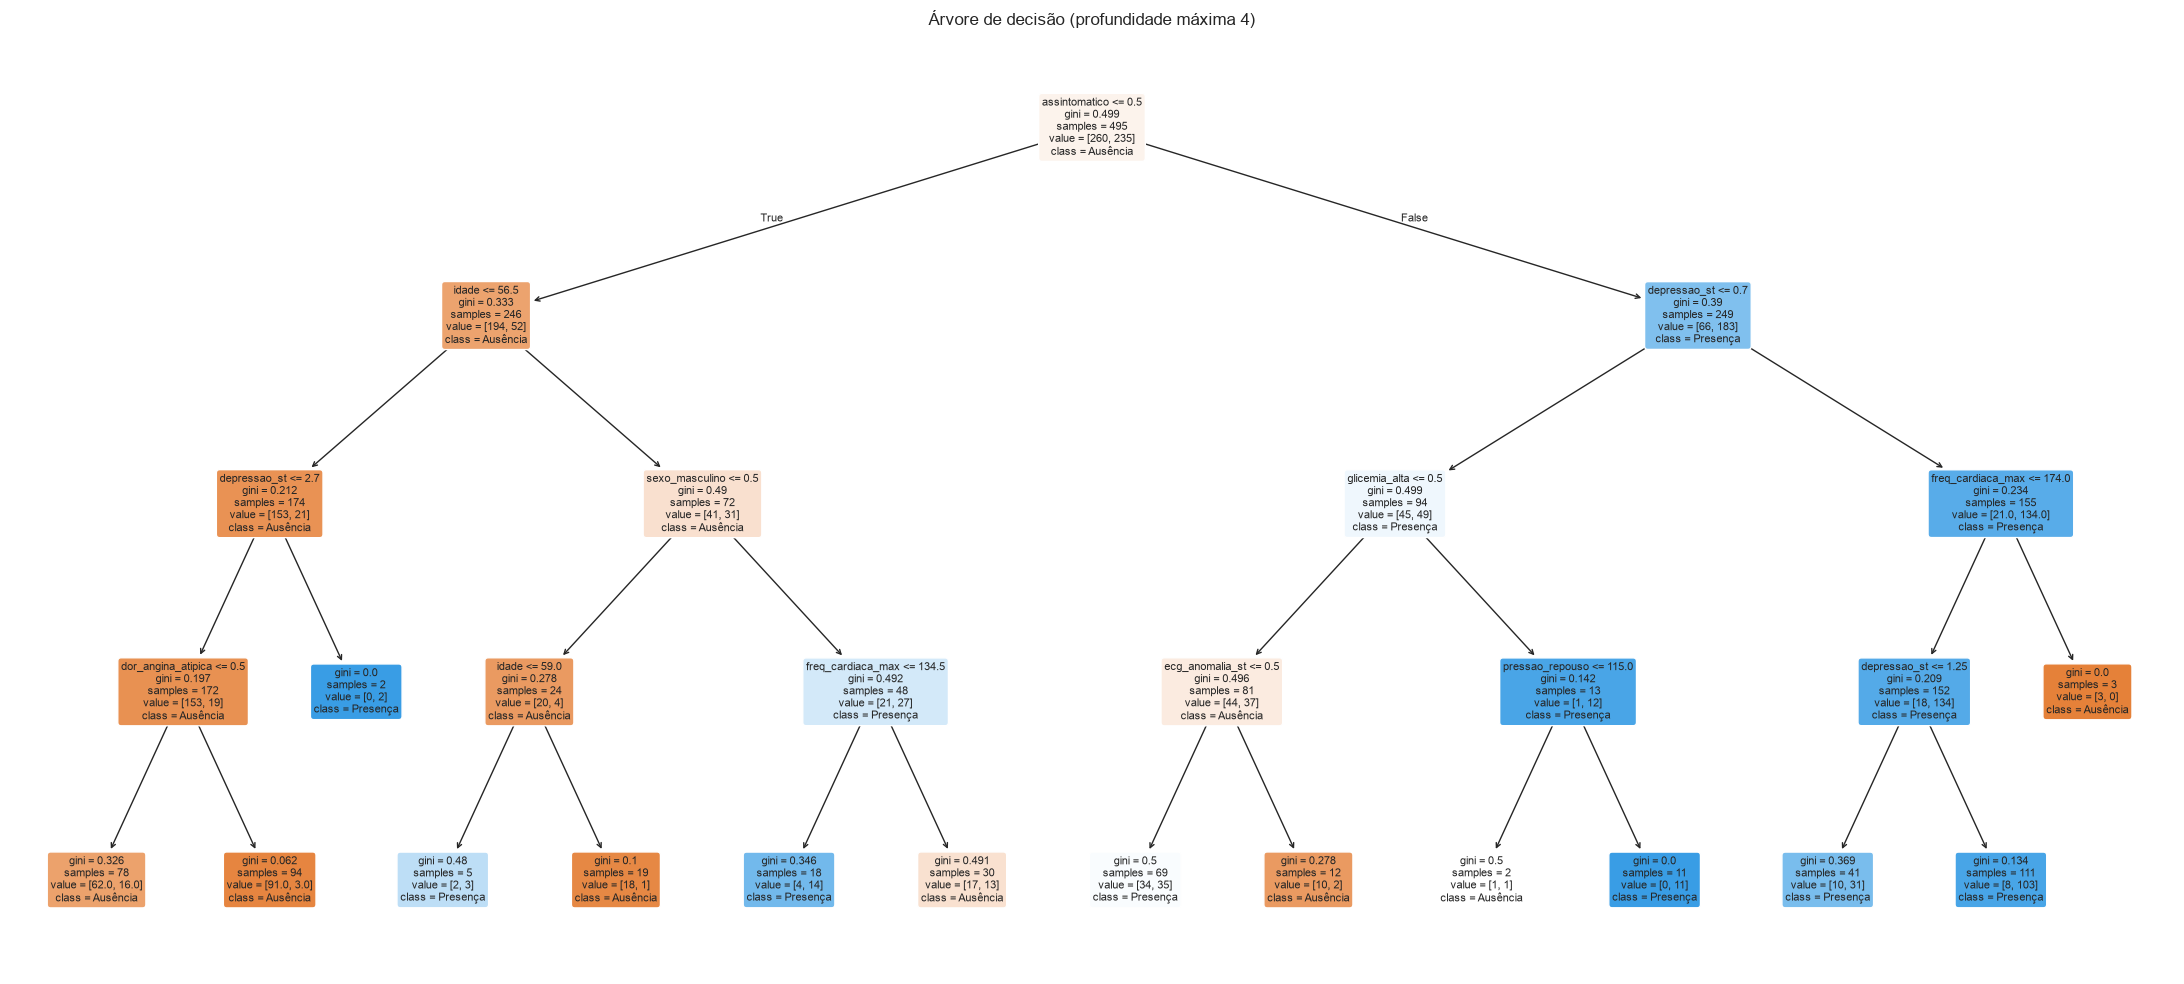

In [16]:
plt.figure(figsize=(22, 10))
plot_tree(
    modelo,
    feature_names=list(X.columns),
    class_names=["Ausência", "Presença"],
    filled=True,
    rounded=True,
    fontsize=8,
)
plt.title("Árvore de decisão (profundidade máxima 4)")
plt.tight_layout()
plt.show()


## Exemplo de previsão para uma ficha nova

A ficha abaixo não está no treino. Ela descreve um paciente de 62 anos, sexo masculino, sem queixa de dor típica (código assintomático), pressão 150, colesterol 280, eletrocardiograma com hipertrofia, frequência máxima 115, angina no exercício e depressão de ST de 2,2.

O modelo devolve a classe aprendida. Isso ilustra a técnica. Não é um diagnóstico e não deve ser usado para decidir cuidado de uma pessoa.

In [17]:
ficha_nova = pd.DataFrame([{
    "age": 62,
    "sex": 1,
    "cp": 4,
    "trestbps": 150,
    "chol": 280,
    "fbs": 0,
    "restecg": 2,
    "thalach": 115,
    "exang": 1,
    "oldpeak": 2.2,
}])

X_nova = montar_atributos(ficha_nova).reindex(columns=X.columns, fill_value=0)
classe = modelo.predict(X_nova)[0]
nomes_classe = {0: "ausência", 1: "presença"}
print("Classe prevista:", nomes_classe[int(classe)])


Classe prevista: presença


## Interpretação e aplicação possível

Os exames que mais separam os perfis são a frequência cardíaca máxima, a angina de exercício, a depressão de ST e o tipo de dor. O grupo de maior risco clínico concentra a maior parte das fichas com presença da doença. A árvore acerta acima do chute da classe mais comum, então os exames carregam informação útil para a classe.

Uma aplicação possível, só como exercício de gestão da informação, é organizar filas de revisão de fichas em um arquivo histórico: fichas com o perfil de maior risco poderiam ser conferidas primeiro por um profissional. O resultado deste notebook não autoriza essa fila num hospital real.

## Limitações

- Os pacientes foram avaliados no fim dos anos 1980, em centros que já investigavam doença coronariana. Não representam a população geral.
- Associação não é causa. Ver colesterol ou dor junto com a classe não prova que aquele exame produziu a doença.
- A Suíça inteira ficou de fora porque o colesterol não foi registrado. Long Beach continua com proporção de doença bem mais alta que Cleveland e Hungria. Parte do padrão pode refletir o mix de hospitais.
- `ca`, `thal` e `slope` foram retirados por falta de preenchimento. Em Cleveland eles existem e são clinicamente importantes. O modelo não os vê.
- O Silhouette dos grupos é baixo. Os grupos são tendências, não caixas fechadas.
- A árvore foi limitada a quatro níveis e testada em cerca de um quarto das fichas. Outra divisão treino/teste muda os números.
- Este trabalho não é um dispositivo de diagnóstico.

## Referência

Janosi, A., Steinbrunn, W., Pfisterer, M., & Detrano, R. (1989). **Heart Disease** [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C52P4X

Página da base: https://archive.ics.uci.edu/dataset/45/heart+disease